In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
# 在Jupyter notebook中内联显示图表
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm  # 进度条库
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms

print(sys.version_info)

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)



transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.FashionMNIST(root='./data',train=True,download=True,transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)



class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print(f"类别数量: {len(class_names)}")
print(f"类别标签: {class_names}")

sys.version_info(major=3, minor=13, micro=5, releaselevel='final', serial=0)
cuda:0
类别数量: 10
类别标签: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


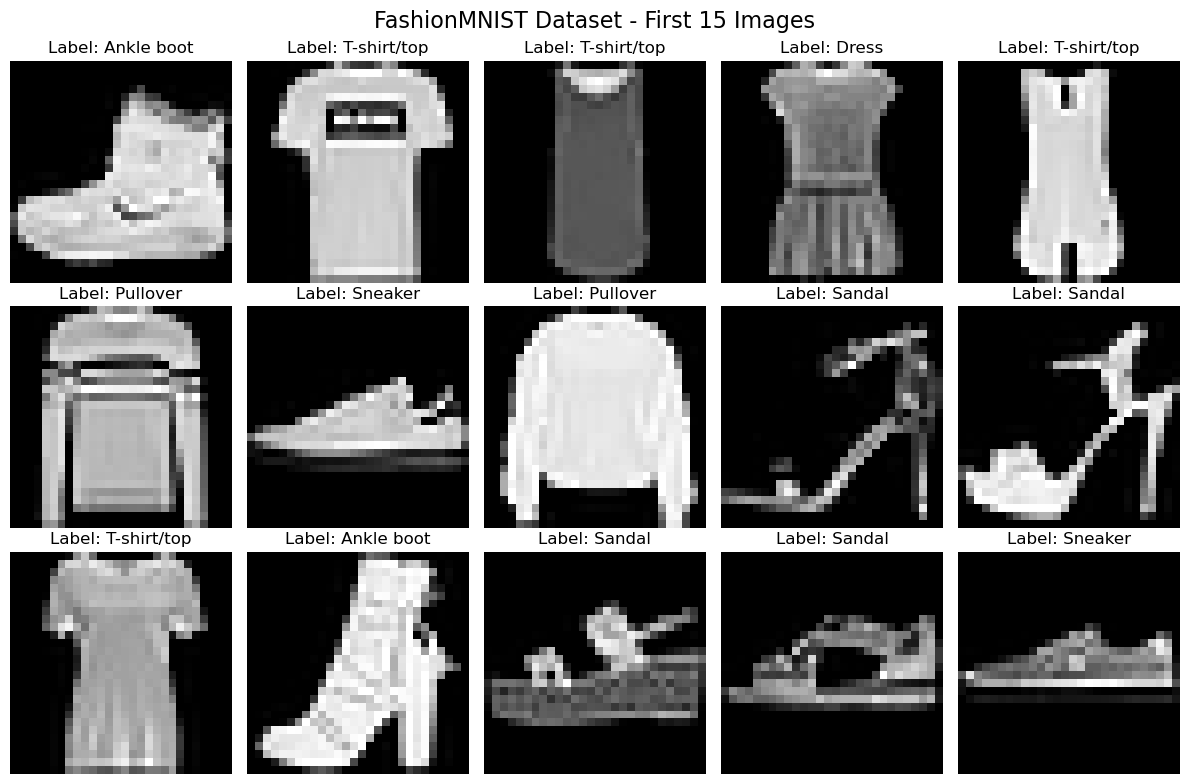

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(3,5,figsize=(12, 8))
fig.suptitle('FashionMNIST Dataset - First 15 Images', fontsize=16)

for i in range(15):
    # Convert tensor to numpy array
    image, label = train_dataset[i]
    image_np = image.squeeze().numpy()

    
    ax[i//5, i%5].imshow(image_np, cmap='gray')
    ax[i//5, i%5].set_title(f'Label: {class_names[label]}')
    ax[i//5, i%5].axis('off')

plt.tight_layout()
plt.show()


In [3]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset,batch_size=batch_size,shuffle=False)

train_iter = iter(train_loader)
batch_images, batch_labels = next(train_iter)

In [4]:
#模型搭建

import torch
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace=True)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 3 * 3, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        
        x = self.relu(self.conv3(x))
        x = self.relu(self.conv4(x))
        x = self.pool(x)
        
        x = self.relu(self.conv5(x))
        x = self.relu(self.conv6(x))
        x=self.pool(x)

        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNN()

dummy_input = torch.randn(32, 1, 28, 28)
output = model(dummy_input)
print(output.shape)

total_params = 0
for name, param in model.named_parameters():
    if param.requires_grad:
        num_params = param.numel()
        total_params += num_params
        print(name,":",num_params)

print(f"Total number of parameters: {total_params}")

torch.Size([32, 10])
conv1.weight : 288
conv1.bias : 32
conv2.weight : 9216
conv2.bias : 32
conv3.weight : 18432
conv3.bias : 64
conv4.weight : 36864
conv4.bias : 64
conv5.weight : 73728
conv5.bias : 128
conv6.weight : 147456
conv6.bias : 128
fc1.weight : 147456
fc1.bias : 128
fc2.weight : 1280
fc2.bias : 10
Total number of parameters: 435306


In [ ]:
#train
import torch.optim as optim
import my_trainer as mt

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

trainer = mt.Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    eval_step=500
)

num_epochs = 20

trainer.train(num_epochs=num_epochs)


[Step 500] Val Loss: 0.5464 Val Acc: 0.7906
[Step 1000] Val Loss: 0.4489 Val Acc: 0.8381
[Step 1500] Val Loss: 0.3713 Val Acc: 0.8588
Epoch [1/20]  Train Loss: 0.4885  Train Acc: 0.8184
[Step 2000] Val Loss: 0.3550 Val Acc: 0.8731
[Step 2500] Val Loss: 0.3278 Val Acc: 0.8807
[Step 3000] Val Loss: 0.3000 Val Acc: 0.8896
[Step 3500] Val Loss: 0.3049 Val Acc: 0.8863
Epoch [2/20]  Train Loss: 0.2972  Train Acc: 0.8895
[Step 4000] Val Loss: 0.3019 Val Acc: 0.8941
[Step 4500] Val Loss: 0.2816 Val Acc: 0.8997
[Step 5000] Val Loss: 0.2678 Val Acc: 0.8994
[Step 5500] Val Loss: 0.2610 Val Acc: 0.9073
Epoch [3/20]  Train Loss: 0.2469  Train Acc: 0.9093
[Step 6000] Val Loss: 0.2556 Val Acc: 0.9061
[Step 6500] Val Loss: 0.2457 Val Acc: 0.9122
[Step 7000] Val Loss: 0.2393 Val Acc: 0.9121
[Step 7500] Val Loss: 0.2417 Val Acc: 0.9124
Epoch [4/20]  Train Loss: 0.2138  Train Acc: 0.9210
[Step 8000] Val Loss: 0.2551 Val Acc: 0.9068
[Step 8500] Val Loss: 0.2485 Val Acc: 0.9067
[Step 9000] Val Loss: 0.2518

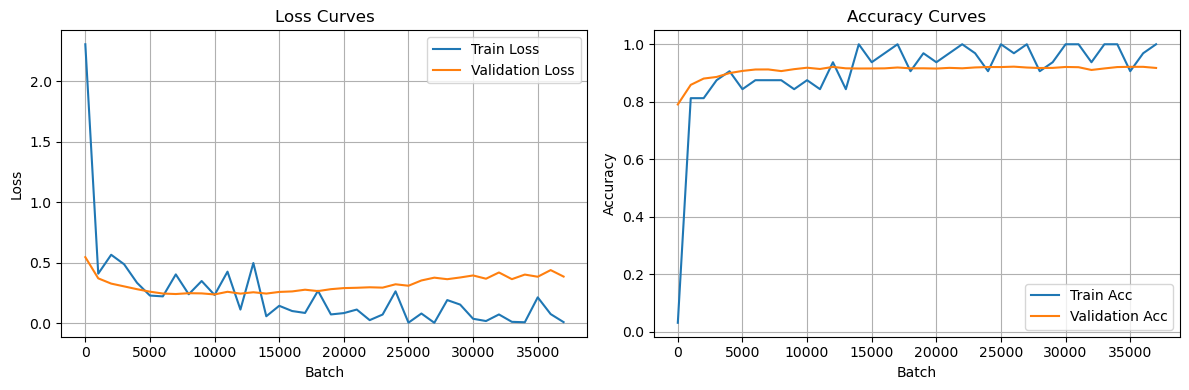

In [6]:
trainer.plot_curves()

In [5]:
import torch
from torch.utils.data import DataLoader

loader = torch.utils.data.DataLoader(train_dataset, batch_size=5000, shuffle=False, num_workers=0)  # 构建数据加载器，一次加载5000张图片
n_samples = 0
mean = 0.0
std = 0.0

for images, _ in loader:  # 遍历数据加载器，每个batch返回(images, labels)
    # images: [batch_size, 1, 28, 28]
    batch_samples = images.size(0)  # 当前batch的图片张数
    images = images.view(batch_samples, -1)  # 展平图片为二维，方便计算，[batch_size, 784]
    mean += images.mean(1).sum()    # 计算每张图片的均值后求和，累加到总均值
    std += images.std(1).sum()      # 计算每张图片的标准差后求和，累加到总标准差
    n_samples += batch_samples      # 累加样本数量

mean /= n_samples  # 求所有图片均值的均值
std /= n_samples   # 求所有图片标准差的均值

print(f"训练集归一化后的均值: {mean.item():.4f}")      # 打印训练集归一化后的均值
print(f"训练集归一化后的标准差: {std.item():.4f}")     # 打印训练集归一化后的标准差

训练集归一化后的均值: 0.2860
训练集归一化后的标准差: 0.3205


In [6]:
mean = 0.
std = 0.
n_pixels = 0

for images, _ in loader:
    batch_pixels = images.numel()
    mean += images.sum()
    std  += (images ** 2).sum()
    n_pixels += batch_pixels

mean /= n_pixels
std = torch.sqrt(std / n_pixels - mean ** 2)

print(mean.item(), std.item())

batch_size = 32

train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True,num_workers=2)

test_loader = DataLoader(test_dataset,batch_size=batch_size,shuffle=False,num_workers=2)

0.28604060411453247 0.3530242443084717


In [7]:
import torch.nn as nn

class TwoLayerNet(nn.Module):
    def __init__(self):
        super(TwoLayerNet, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 300)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(300, 100)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(100, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x
    
model_normalize = TwoLayerNet()
print(model_normalize)
print(model_normalize.state_dict())


TwoLayerNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=300, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=300, out_features=100, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=100, out_features=10, bias=True)
)
OrderedDict({'fc1.weight': tensor([[-0.0127, -0.0156,  0.0269,  ...,  0.0229, -0.0073,  0.0025],
        [-0.0108, -0.0051, -0.0282,  ..., -0.0277,  0.0241, -0.0325],
        [ 0.0170, -0.0253, -0.0079,  ...,  0.0264,  0.0177,  0.0223],
        ...,
        [-0.0174,  0.0042,  0.0287,  ...,  0.0225, -0.0260, -0.0063],
        [ 0.0212,  0.0115,  0.0257,  ..., -0.0159, -0.0328,  0.0283],
        [-0.0330, -0.0087, -0.0153,  ...,  0.0051,  0.0139,  0.0180]]), 'fc1.bias': tensor([ 0.0293,  0.0328, -0.0275, -0.0162,  0.0133, -0.0048, -0.0171, -0.0335,
        -0.0122, -0.0117, -0.0339, -0.0104,  0.0339, -0.0254, -0.0166, -0.0029,
        -0.0139, -0.0075,  0.0187, -0.0332,  0.0078, -0.0306,  0.0284,  0.0045,
    

In [ ]:
import torch.nn as nn
import torch.optim as optim
import CNN_trainer as mt

criterion = nn.CrossEntropyLoss()

optimizer_normalize = optim.Adam(model_normalize.parameters(), lr=0.001)

trainer_normalize = mt.Trainer(
    model=model_normalize,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer_normalize,
    device=device
)

num_epochs = 20
trainer_normalize.train(num_epochs)

[Step 100] Val Loss: 0.8054 Val Acc: 0.6986
[Step 200] Val Loss: 0.6257 Val Acc: 0.7742
[Step 300] Val Loss: 0.5823 Val Acc: 0.7874
[Step 400] Val Loss: 0.5488 Val Acc: 0.8042
[Step 500] Val Loss: 0.5400 Val Acc: 0.8009
[Step 600] Val Loss: 0.4682 Val Acc: 0.8318
[Step 700] Val Loss: 0.5028 Val Acc: 0.8207
[Step 800] Val Loss: 0.5085 Val Acc: 0.8177
[Step 900] Val Loss: 0.4641 Val Acc: 0.8332
[Step 1000] Val Loss: 0.4607 Val Acc: 0.8336
[Step 1100] Val Loss: 0.4378 Val Acc: 0.8438
[Step 1200] Val Loss: 0.5231 Val Acc: 0.8180
[Step 1300] Val Loss: 0.4177 Val Acc: 0.8492
[Step 1400] Val Loss: 0.4733 Val Acc: 0.8210
[Step 1500] Val Loss: 0.4161 Val Acc: 0.8510
[Step 1600] Val Loss: 0.4298 Val Acc: 0.8429
[Step 1700] Val Loss: 0.4328 Val Acc: 0.8465
[Step 1800] Val Loss: 0.4029 Val Acc: 0.8514
Epoch [1/20]  Train Loss: 0.4966  Train Acc: 0.8212
[Step 1900] Val Loss: 0.4138 Val Acc: 0.8514
[Step 2000] Val Loss: 0.4537 Val Acc: 0.8321
[Step 2100] Val Loss: 0.4283 Val Acc: 0.8426
[Step 2200] 

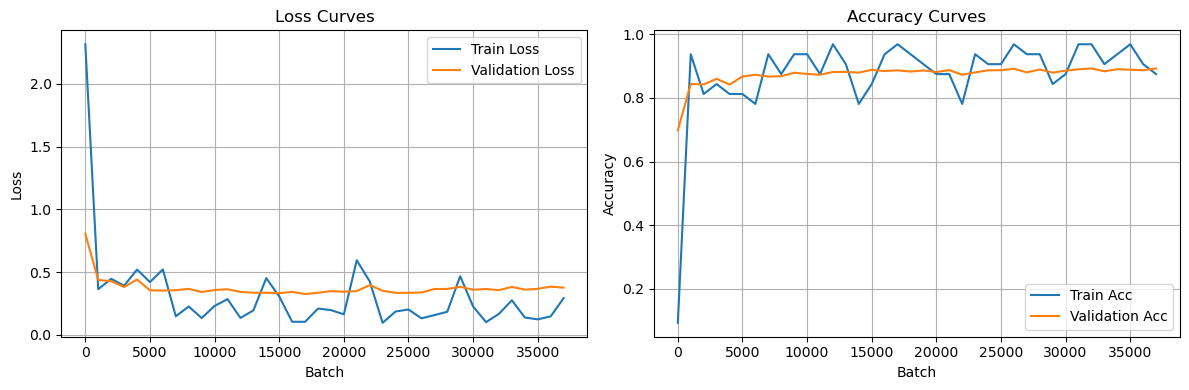

In [9]:
trainer_normalize.plot_curves()